# To analyze final data

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 160)

In [2]:
# Change this to your final test output folder
ROOT = Path("Results/final_test_CPU")

TEST_ALL_DIR = ROOT / "test_all"
SUMMARY_PATH = ROOT / "final_test_summary.csv"

CLASSES = [
    "Amphibia",
    "Animalia",
    "Arachnida",
    "Aves",
    "Fungi",
    "Insecta",
    "Mammalia",
    "Mollusca",
    "Plantae",
    "Reptilia",
]

In [3]:
summary_df = pd.read_csv(SUMMARY_PATH)
summary_df

,checkpoint,model_name,model_type,dropout,img_size,aug,seed,domain,use_segmented_test,loss,accuracy,macro_accuracy,macro_precision,macro_auc,weighted_auc
0,final_models/complex_inception_p0.pt,complex_inception_p0,complex_inception,0.3,224,random_resized_crop,42,normal,False,1.474400,0.5200,0.5200,0.539268,0.887142,0.887142
1,final_models/complex_inception_p025.pt,complex_inception_p025,complex_inception,0.3,224,random_resized_crop,42,normal,False,1.405064,0.5235,0.5235,0.552073,0.891428,0.891428
2,final_models/complex_inception_p1.pt,complex_inception_p1,complex_inception,0.3,224,random_resized_crop,42,normal,False,2.157078,0.2805,0.2805,0.309208,0.735698,0.735698
3,final_models/custom_025.pt,custom_025,custom,0.3,224,random_resized_crop,42,normal,False,1.504536,0.5345,0.5345,0.537920,0.881971,0.881971
4,final_models/custom_p0.pt,custom_p0,custom,0.3,224,random_resized_crop,42,normal,False,1.624949,0.5435,0.5435,0.553740,0.886595,0.886595
5,final_models/custom_p1.pt,custom_p1,custom,0.3,224,random_resized_crop,42,normal,False,2.871158,0.2405,0.2405,0.278363,0.697245,0.697245
6,final_models/resnet18_025.pt,resnet18_025,resnet18,0.3,224,random_resized_crop,42,normal,False,0.782283,0.7460,0.7460,0.750215,0.964930,0.964930
7,final_models/resnet18_p0.pt,resnet18_p0,resnet18,0.3,224,random_resized_crop,42,normal,False,0.804831,0.7395,0.7395,0.740909,0.962884,0.962884
8,final_models/resnet18_p1.pt,resnet18_p1,resnet18,0.3,224,random_resized_crop,42,normal,False,1.009222,0.6740,0.6740,0.680279,0.943993,0.943993


In [4]:
print(summary_df.sort_values("accuracy", ascending=False))

                               checkpoint              model_name         model_type  dropout  img_size                  aug  seed  domain  \
6            final_models/resnet18_025.pt            resnet18_025           resnet18      0.3       224  random_resized_crop    42  normal   
7             final_models/resnet18_p0.pt             resnet18_p0           resnet18      0.3       224  random_resized_crop    42  normal   
8             final_models/resnet18_p1.pt             resnet18_p1           resnet18      0.3       224  random_resized_crop    42  normal   
4               final_models/custom_p0.pt               custom_p0             custom      0.3       224  random_resized_crop    42  normal   
3              final_models/custom_025.pt              custom_025             custom      0.3       224  random_resized_crop    42  normal   
1  final_models/complex_inception_p025.pt  complex_inception_p025  complex_inception      0.3       224  random_resized_crop    42  normal   
0    f

In [5]:
# Read all test_class_metrics files
dfs = []

for path in ROOT.rglob("test_class_metrics_*.csv"):
    model_name = path.parent.name
    domain = path.stem.replace("test_class_metrics_", "")

    df = pd.read_csv(path)
    df["model_name"] = model_name
    df["domain"] = domain
    dfs.append(df)

test_class_metrics = pd.concat(dfs, ignore_index=True)

# Fix naming inconsistency
test_class_metrics["model_name"] = (
    test_class_metrics["model_name"]
    .str.replace("resnet18_025", "resnet18_p025", regex=False)
)
test_class_metrics["model_name"] = (
    test_class_metrics["model_name"]
    .str.replace("custom_025", "custom_p025", regex=False)
)

test_class_metrics

,class,support,precision,recall,auc,model_name,domain
0,Amphibia,200,0.373770,0.570,0.859133,custom_p0,normal
1,Animalia,200,0.473430,0.490,0.864033,custom_p0,normal
2,Arachnida,200,0.616279,0.530,0.875164,custom_p0,normal
3,Aves,200,0.564220,0.615,0.914211,custom_p0,normal
4,Fungi,200,0.649533,0.695,0.921242,custom_p0,normal
...,...,...,...,...,...,...,...
85,Insecta,200,0.731343,0.735,0.953414,resnet18_p0,normal
86,Mammalia,200,0.736041,0.725,0.966456,resnet18_p0,normal
87,Mollusca,200,0.704663,0.680,0.958114,resnet18_p0,normal
88,Plantae,200,0.707763,0.775,0.972431,resnet18_p0,normal


In [6]:
class_dfs = {
    cls: (
        test_class_metrics[test_class_metrics["class"] == cls]
        .sort_values(["domain", "recall"], ascending=[True, False])
        .reset_index(drop=True)
    )
    for cls in CLASSES
}

In [7]:
def compare_class(cls, metric="recall", domain=None):
    df = class_dfs[cls].copy()

    if domain is not None:
        df = df[df["domain"] == domain]

    return df.sort_values(metric, ascending=False)

In [8]:
def pivot_metric(metric="recall", domain=None):
    df = test_class_metrics.copy()

    if domain is not None:
        df = df[df["domain"] == domain]

    return df.pivot_table(
        index="class",
        columns="model_name",
        values=metric,
        aggfunc="mean",
    ).loc[CLASSES]

In [9]:
pivot_metric("auc")

model_name,complex_inception_p0,complex_inception_p025,complex_inception_p1,custom_p0,custom_p025,custom_p1,resnet18_p0,resnet18_p025,resnet18_p1
class,,,,,,,,,
Amphibia,0.869694,0.857206,0.667256,0.859133,0.855136,0.641344,0.959453,0.959894,0.939744
Animalia,0.892953,0.890464,0.710617,0.864033,0.873556,0.680986,0.944436,0.948989,0.926503
Arachnida,0.879294,0.873475,0.685933,0.875164,0.876167,0.670642,0.957803,0.964011,0.943256
Aves,0.906558,0.901833,0.746936,0.914211,0.913583,0.685692,0.984736,0.985814,0.976325
Fungi,0.910064,0.906411,0.769556,0.921242,0.911922,0.692333,0.975833,0.979294,0.952339
Insecta,0.860536,0.873244,0.700294,0.846433,0.851600,0.666467,0.953414,0.959339,0.929075
Mammalia,0.912447,0.917617,0.758200,0.910981,0.912511,0.750406,0.966456,0.964725,0.952339
Mollusca,0.887036,0.893819,0.761428,0.879794,0.869942,0.719758,0.958114,0.956067,0.933836
Plantae,0.936131,0.945436,0.829878,0.953778,0.940194,0.802464,0.972431,0.971875,0.951778


In [10]:
compare_class("Aves", metric="model_name")

,class,support,precision,recall,auc,model_name,domain
2,Aves,200,0.847953,0.725,0.976325,resnet18_p1,normal
1,Aves,200,0.876289,0.850,0.985814,resnet18_p025,normal
0,Aves,200,0.822967,0.860,0.984736,resnet18_p0,normal
8,Aves,200,0.295455,0.130,0.685692,custom_p1,normal
4,Aves,200,0.505976,0.635,0.913583,custom_p025,normal
5,Aves,200,0.564220,0.615,0.914211,custom_p0,normal
7,Aves,200,0.395349,0.255,0.746936,complex_inception_p1,normal
6,Aves,200,0.491379,0.570,0.901833,complex_inception_p025,normal
3,Aves,200,0.454248,0.695,0.906558,complex_inception_p0,normal


In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

def delta_heatmap(
    df,
    metric="recall",
    baseline_contains="p0",
    compare_contains="p025",
    domain=None,
):
    data = df.copy()

    if domain is not None:
        data = data[data["domain"] == domain]

    baseline = data[data["model_name"].str.contains(baseline_contains, regex=False)].copy()
    compare = data[data["model_name"].str.contains(compare_contains, regex=False)].copy()

    # You may need to clean model names so the same architecture matches
    baseline["arch"] = baseline["model_name"].str.replace(baseline_contains, "", regex=False)
    compare["arch"] = compare["model_name"].str.replace(compare_contains, "", regex=False)

    merged = compare.merge(
        baseline,
        on=["class", "arch", "domain"],
        suffixes=("_compare", "_baseline"),
    )

    merged[f"delta_{metric}"] = merged[f"{metric}_compare"] - merged[f"{metric}_baseline"]

    pivot = merged.pivot_table(
        index="class",
        columns="arch",
        values=f"delta_{metric}",
        aggfunc="mean",
    )

    plt.figure(figsize=(10, 5))
    sns.heatmap(
        pivot,
        annot=True,
        center=0,
        cmap="coolwarm",
        fmt=".3f",
    )
    plt.title(f"Change in {metric}: {compare_contains} minus {baseline_contains}")
    plt.ylabel("Class")
    plt.xlabel("Model")
    plt.tight_layout()
    plt.show()

    return merged

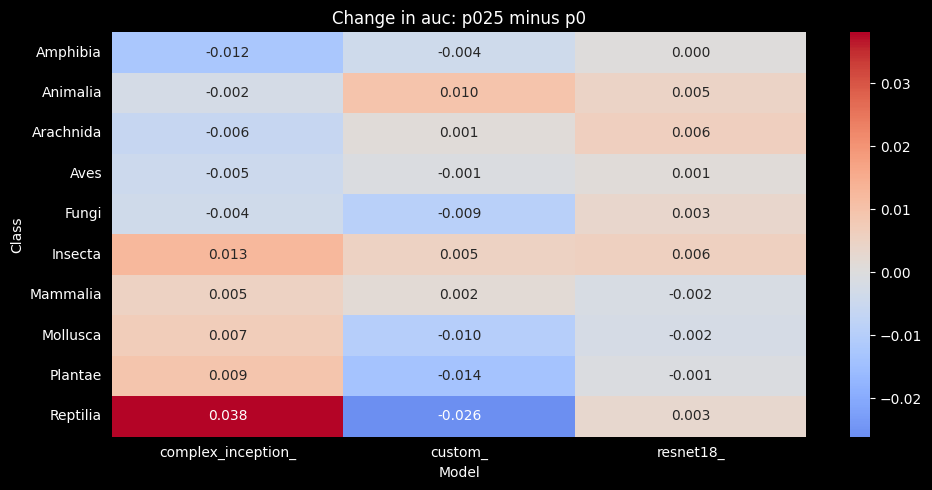

In [12]:
delta_auc = delta_heatmap(
    test_class_metrics,
    metric="auc",
    baseline_contains="p0",
    compare_contains="p025",
)

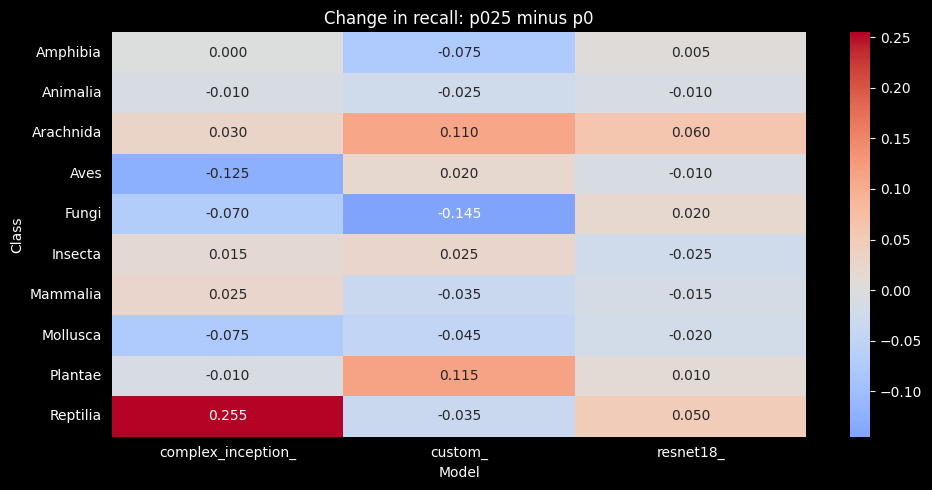

In [13]:
delta_recall = delta_heatmap(
    test_class_metrics,
    metric="recall",
    baseline_contains="p0",
    compare_contains="p025",
)

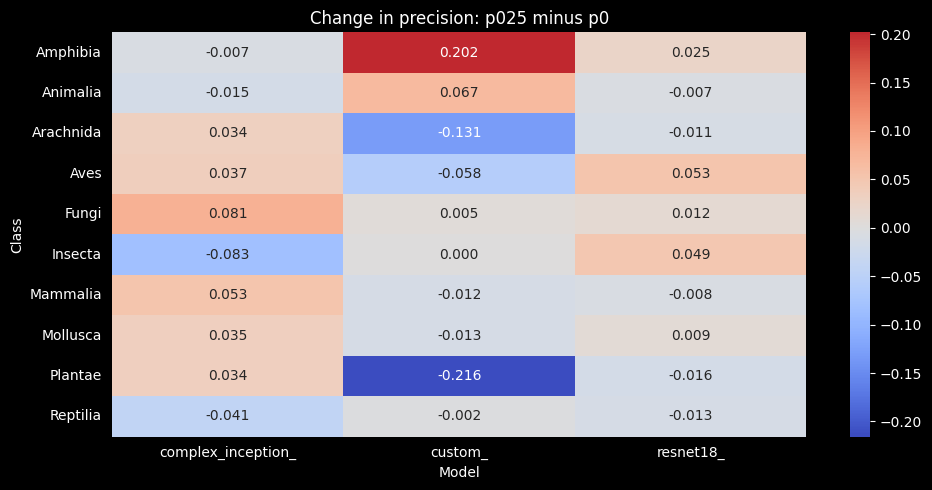

In [14]:
delta_prec = delta_heatmap(
    test_class_metrics,
    metric="precision",
    baseline_contains="p0",
    compare_contains="p025",
)

## Final plots

* Decision to use custom model instead of inception one

In [15]:
df = test_class_metrics.copy()

# Keep only the 6 relevant models
keep_models = [
    "custom_p0", "custom_p025", "custom_p1",
    "resnet18_p0", "resnet18_p025", "resnet18_p1",
]
df = df[df["model_name"].isin(keep_models)].copy()

# Split into architecture + setup
df["arch"] = df["model_name"].str.extract(r"^(custom|resnet18)")
df["setup"] = df["model_name"].str.extract(r"(p0|p025|p1)$")

### Overview table

In [16]:
overview = (
    df.groupby(["arch", "setup"], as_index=False)[["auc", "recall", "precision"]]
      .mean()
)

setup_order = {"p0": 0, "p025": 1, "p1": 2}
arch_order = {"resnet18": 0, "custom": 1}

overview["arch_order"] = overview["arch"].map(arch_order)
overview["setup_order"] = overview["setup"].map(setup_order)

overview = (
    overview.sort_values(["arch_order", "setup_order"])
            .drop(columns=["arch_order", "setup_order"])
            .reset_index(drop=True)
)

overview_round = overview.copy()
overview_round[["auc", "recall", "precision"]] = overview_round[["auc", "recall", "precision"]].round(3)
overview_round

,arch,setup,auc,recall,precision
0,resnet18,p0,0.963,0.739,0.741
1,resnet18,p025,0.965,0.746,0.750
2,resnet18,p1,0.944,0.674,0.680
3,custom,p0,0.887,0.544,0.554
4,custom,p025,0.882,0.534,0.538
5,custom,p1,0.697,0.240,0.278


In [17]:
def make_delta_long(df):
    metrics = ["auc", "recall", "precision"]
    out = []

    for metric in metrics:
        base = (
            df[df["setup"] == "p0"][["class", "arch", metric]]
            .rename(columns={metric: "baseline"})
        )
        p025 = (
            df[df["setup"] == "p025"][["class", "arch", metric]]
            .rename(columns={metric: "p025"})
        )

        merged = p025.merge(base, on=["class", "arch"], how="left")
        merged["metric"] = metric
        merged["delta"] = merged["p025"] - merged["baseline"]
        out.append(merged[["class", "arch", "metric", "delta"]])

    return pd.concat(out, ignore_index=True)

delta_long = make_delta_long(df)
delta_long.head()

,class,arch,metric,delta
0,Amphibia,custom,auc,-0.003997
1,Animalia,custom,auc,0.009522
2,Arachnida,custom,auc,0.001003
3,Aves,custom,auc,-0.000628
4,Fungi,custom,auc,-0.009319


In [40]:
overview = (
    df.groupby(["arch", "setup"], as_index=False)[["auc", "recall", "precision"]]
      .mean()
)

setup_order = {"p0": 0, "p025": 1, "p1": 2}
arch_order = {"resnet18": 0, "custom": 1}

overview["arch_order"] = overview["arch"].map(arch_order)
overview["setup_order"] = overview["setup"].map(setup_order)

overview = (
    overview.sort_values(["arch_order", "setup_order"])
            .drop(columns=["arch_order", "setup_order"])
            .reset_index(drop=True)
)

print(overview)

       arch setup       auc  recall  precision
0  resnet18    p0  0.962884  0.7395   0.740909
1  resnet18  p025  0.964930  0.7460   0.750215
2  resnet18    p1  0.943993  0.6740   0.680279
3    custom    p0  0.886595  0.5435   0.553740
4    custom  p025  0.881971  0.5345   0.537920
5    custom    p1  0.697245  0.2405   0.278363


In [19]:
def build_heatmap_matrix(delta_long, version="by_model"):
    if version == "by_model":
        spec = [
            ("resnet18", "auc",       "resnet18_auc",       "AUC"),
            ("resnet18", "recall",    "resnet18_recall",    "Recall"),
            ("resnet18", "precision", "resnet18_precision", "Precision"),
            ("custom",   "auc",       "custom_auc",         "AUC"),
            ("custom",   "recall",    "custom_recall",      "Recall"),
            ("custom",   "precision", "custom_precision",   "Precision"),
        ]

    elif version == "by_metric":
        spec = [
            ("resnet18", "auc",       "resnet18_auc",       "ResNet18"),
            ("custom",   "auc",       "custom_auc",         "Custom CNN"),
            ("resnet18", "recall",    "resnet18_recall",    "ResNet18"),
            ("custom",   "recall",    "custom_recall",      "Custom CNN"),
            ("resnet18", "precision", "resnet18_precision", "ResNet18"),
            ("custom",   "precision", "custom_precision",   "Custom CNN"),
        ]

    else:
        raise ValueError("version must be 'by_model' or 'by_metric'")

    mat = pd.DataFrame(index=CLASSES)

    for arch, metric, internal_col, display_label in spec:
        sub = (
            delta_long[
                (delta_long["arch"] == arch) &
                (delta_long["metric"] == metric)
            ][["class", "delta"]]
            .set_index("class")
        )

        mat[internal_col] = sub["delta"]

    mat = mat.loc[CLASSES]

    auc_cols = [i for i, (_, metric, _, _) in enumerate(spec) if metric == "auc"]
    other_cols = [i for i, (_, metric, _, _) in enumerate(spec) if metric in {"recall", "precision"}]
    display_labels = [display_label for _, _, _, display_label in spec]

    return mat, auc_cols, other_cols, display_labels

In [20]:
def add_group_bracket_data(ax, x0, x1, label, y=-0.65, h=0.22):
    """
    Draw bracket in heatmap data coordinates.
    Works because we later extend y-limits above the first row.
    """
    color = "#333333"

    ax.plot([x0, x1], [y, y], color=color, lw=1.2, clip_on=False)
    ax.plot([x0, x0], [y, y + h], color=color, lw=1.2, clip_on=False)
    ax.plot([x1, x1], [y, y + h], color=color, lw=1.2, clip_on=False)

    ax.text(
        (x0 + x1) / 2,
        y - 0.13,
        label,
        ha="center",
        va="bottom",
        fontsize=12,
        color=color,
    )

In [21]:
from matplotlib.colors import LinearSegmentedColormap

LIGHT_RED_BLUE = LinearSegmentedColormap.from_list(
    "light_red_blue",
    ["#9b3a3a", "#f4f1ee", "#356f9f"],
    # [
    #     "#d88c8c",   # soft red
    #     "#f7f7f7",   # near white / neutral
    #     "#8fb7d9",   # soft blue
    # ],
    N=256,
)

cmap = LinearSegmentedColormap.from_list(
        "soft_red_blue",
        ["#9b3a3a", "#f4f1ee", "#356f9f"],
        N=256,
    )

In [47]:
def plot_single_combined_heatmap(mat, auc_cols, other_cols, display_labels, title=None):
    # Font sizes
    annot_fs = 13
    tick_fs = 13
    cbar_title_fs = 13
    cbar_tick_fs = 12

    # Figure with 1 heatmap axis + 2 colorbar axes
    fig = plt.figure(figsize=(10, 6))
    gs = fig.add_gridspec(1, 3, width_ratios=[30, 1.2, 1.2], wspace=0.3)

    ax = fig.add_subplot(gs[0, 0])
    cax_auc = fig.add_subplot(gs[0, 1])
    cax_other = fig.add_subplot(gs[0, 2])

    vals = mat.values.astype(float)

    # Masks
    mask_auc = np.ones_like(vals, dtype=bool)
    mask_auc[:, auc_cols] = False

    mask_other = np.ones_like(vals, dtype=bool)
    mask_other[:, other_cols] = False

    # First layer: AUC columns only
    sns.heatmap(
        mat,
        mask=mask_auc,
        ax=ax,
        cmap=LIGHT_RED_BLUE,
        center=0,
        vmin=-0.027,
        vmax=0.027,
        cbar=True,
        cbar_ax=cax_auc,
        annot=False,
        linewidths=0.5,
        linecolor="white",
    )

    # Second layer: Recall + Precision columns only
    sns.heatmap(
        mat,
        mask=mask_other,
        ax=ax,
        cmap=LIGHT_RED_BLUE,
        center=0,
        vmin=-0.27,
        vmax=0.27,
        cbar=True,
        cbar_ax=cax_other,
        annot=False,
        linewidths=0.5,
        linecolor="white",
    )

    # Manual annotations
    for i in range(mat.shape[0]):
        for j in range(mat.shape[1]):
            val = mat.iat[i, j]
            if pd.isna(val):
                continue

            text_color = "#333333"

            ax.text(
                j + 0.5, i + 0.5,
                f"{val:.3f}",
                ha="center",
                va="center",
                fontsize=annot_fs,
                color=text_color,
            )

    # Titles and labels
    if title is None:
        title = "Per-class change from partial segmentation training (p025 - p0)"

    ax.set_xlabel("")
    ax.set_ylabel("")

    ax.set_xticklabels(display_labels, rotation=0, fontsize=tick_fs)
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=tick_fs)
    ax.tick_params(axis="both", labelsize=tick_fs)

    # IMPORTANT: create space above the heatmap for brackets
    n_rows = mat.shape[0]
    ax.set_ylim(n_rows, -1.25)

    # Brackets inside the heatmap axis
    add_group_bracket_data(ax, 0, 3, "ResNet18")
    add_group_bracket_data(ax, 3, 6, "Custom CNN")

    # Colorbar titles
    cax_auc.set_title("AUC", fontsize=cbar_title_fs, pad=8)
    cax_other.set_title("Recall /\nPrecision", fontsize=cbar_title_fs, pad=8)

    # Colorbar tick labels
    cax_auc.tick_params(labelsize=cbar_tick_fs)
    cax_other.tick_params(labelsize=cbar_tick_fs)

    fig.subplots_adjust(
        top=0.84,
        bottom=0.12,
        left=0.12,
        right=0.88,
        wspace=0.25,
    )

    plt.show()

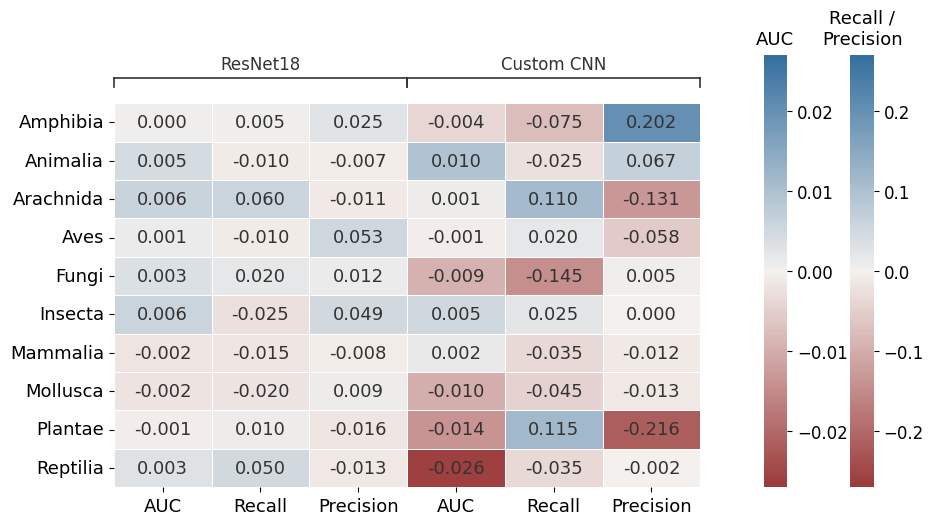

In [48]:
mat_model, auc_cols_model, other_cols_model, labels_model = build_heatmap_matrix(
    delta_long,
    version="by_model"
)

plot_single_combined_heatmap(
    mat_model,
    auc_cols_model,
    other_cols_model,
    labels_model,
    title=" "
)

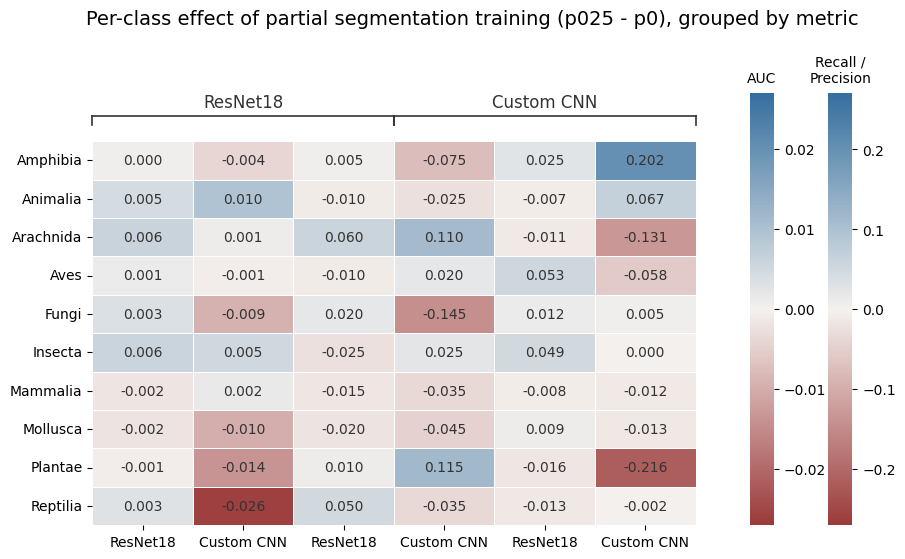

In [35]:
mat_metric, auc_cols_metric, other_cols_metric, labels_model = build_heatmap_matrix(
    delta_long,
    version="by_metric"
)

plot_single_combined_heatmap(
    mat_metric,
    auc_cols_metric,
    other_cols_metric,
    labels_model,
    title="Per-class effect of partial segmentation training (p025 - p0), grouped by metric"
)

# Model plots

In [55]:
from torchinfo import summary
from copy_train_10class import build_model

model = build_model(
    model_type="custom_residual",
    num_classes=10,
    dropout=0.3,
)

summary(
    model,
    input_size=(1, 3, 224, 224),
    col_names=["input_size", "output_size", "num_params", "trainable"],
    depth=4,
)

Layer (type:depth-idx)                   Input Shape               Output Shape              Param #                   Trainable
CustomCNNResidual                        [1, 3, 224, 224]          [1, 10]                   --                        True
├─Sequential: 1-1                        [1, 3, 224, 224]          [1, 256, 1, 1]            --                        True
│    └─ResidualBlock: 2-1                [1, 3, 224, 224]          [1, 32, 112, 112]         --                        True
│    │    └─Sequential: 3-1              [1, 3, 224, 224]          [1, 32, 224, 224]         --                        True
│    │    │    └─Conv2d: 4-1             [1, 3, 224, 224]          [1, 32, 224, 224]         864                       True
│    │    │    └─BatchNorm2d: 4-2        [1, 32, 224, 224]         [1, 32, 224, 224]         64                        True
│    │    │    └─ReLU: 4-3               [1, 32, 224, 224]         [1, 32, 224, 224]         --                        --
│    

In [57]:
from torchinfo import summary
from copy_train_10class import build_model

MODEL_TYPES = [
    "custom",
    "custom_residual",
    "simple_inception",
    "complex_inception",
    "resnet18",
]

for model_type in MODEL_TYPES:
    print("\n" + "=" * 80)
    print(model_type)
    print("=" * 80)

    model = build_model(
        model_type=model_type,
        num_classes=10,
        dropout=0.3,
    )

    summary(
        model,
        input_size=(1, 3, 224, 224),
        col_names=["output_size", "num_params"],
        depth=3,
    )


custom

custom_residual

simple_inception

complex_inception

resnet18


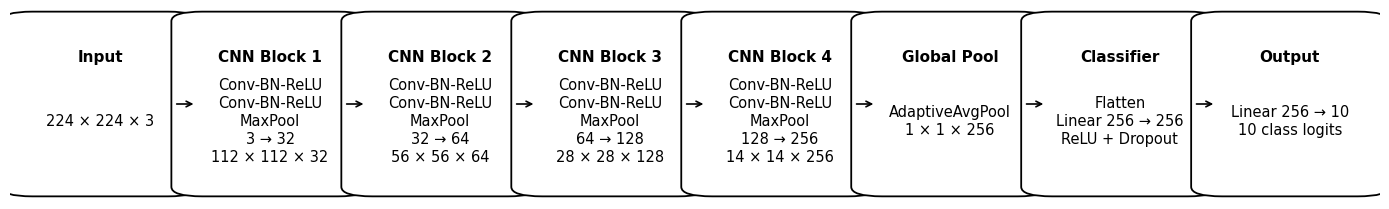

In [83]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch

def draw_custom_cnn_architecture(save_path="custom_cnn_architecture.png"):
    blocks = [
        ("Input", "224 × 224 × 3"),
        ("CNN Block 1", "Conv-BN-ReLU\nConv-BN-ReLU\nMaxPool\n3 → 32\n112 × 112 × 32"),
        ("CNN Block 2", "Conv-BN-ReLU\nConv-BN-ReLU\nMaxPool\n32 → 64\n56 × 56 × 64"),
        ("CNN Block 3", "Conv-BN-ReLU\nConv-BN-ReLU\nMaxPool\n64 → 128\n28 × 28 × 128"),
        ("CNN Block 4", "Conv-BN-ReLU\nConv-BN-ReLU\nMaxPool\n128 → 256\n14 × 14 × 256"),
        ("Global Pool", "AdaptiveAvgPool\n1 × 1 × 256"),
        ("Classifier", "Flatten\nLinear 256 → 256\nReLU + Dropout"),
        ("Output", "Linear 256 → 10\n10 class logits"),
    ]

    fig, ax = plt.subplots(figsize=(14, 2.2))
    ax.axis("off")

    x_start = 0.025
    y = 0.43
    box_w = 0.085
    box_h = 0.32
    gap = 0.014

    for i, (title, text) in enumerate(blocks):
        x = x_start + i * (box_w + gap)

        rect = FancyBboxPatch(
            (x, y),
            box_w,
            box_h,
            boxstyle="round,pad=0.015,rounding_size=0.018",
            linewidth=1.3,
            edgecolor="black",
            facecolor="white",
        )
        ax.add_patch(rect)

        ax.text(
            x + box_w / 2,
            y + box_h * 0.78,
            title,
            ha="center",
            va="center",
            fontsize=11,
            fontweight="bold",
        )

        ax.text(
            x + box_w / 2,
            y + box_h * 0.40,
            text,
            ha="center",
            va="center",
            fontsize=10.5,
            linespacing=1.25,
        )

        if i < len(blocks) - 1:
            arrow_y = y + box_h / 2

            ax.annotate(
                "",
                xy=(x + box_w + gap * 0.85, arrow_y),
                xytext=(x + box_w + gap * 0.15, arrow_y),
                arrowprops=dict(
                    arrowstyle="->",
                    linewidth=1.2,
                    shrinkA=0,
                    shrinkB=0,
                ),
            )

    # ax.text(
    #     0.5,
    #     0.20,
    #     "Each CNN block applies two 3×3 convolutions with batch normalization and ReLU, followed by 2×2 max pooling.",
    #     ha="center",
    #     va="center",
    #     fontsize=9,
    # )

    plt.tight_layout()
    last_x = x_start + (len(blocks) - 1) * (box_w + gap)

    ax.set_xlim(x_start - 0.01, last_x + box_w + 0.01)
    ax.set_ylim(y - 0.02, y + box_h + 0.02)
    plt.savefig(
        save_path,
        dpi=300,
        bbox_inches="tight",
        pad_inches=0.02,
    )
    plt.show()

draw_custom_cnn_architecture()

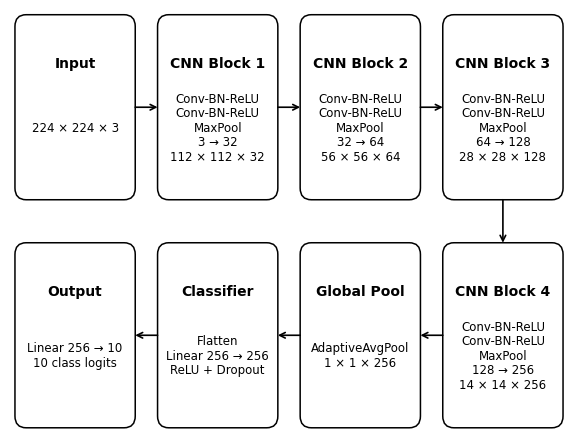

In [7]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch

def draw_custom_cnn_architecture_2row(save_path="custom_cnn_architecture_2row.pdf"):
    blocks = [
        ("Input", "224 × 224 × 3"),
        ("CNN Block 1", "Conv-BN-ReLU\nConv-BN-ReLU\nMaxPool\n3 → 32\n112 × 112 × 32"),
        ("CNN Block 2", "Conv-BN-ReLU\nConv-BN-ReLU\nMaxPool\n32 → 64\n56 × 56 × 64"),
        ("CNN Block 3", "Conv-BN-ReLU\nConv-BN-ReLU\nMaxPool\n64 → 128\n28 × 28 × 128"),
        ("CNN Block 4", "Conv-BN-ReLU\nConv-BN-ReLU\nMaxPool\n128 → 256\n14 × 14 × 256"),
        ("Global Pool", "AdaptiveAvgPool\n1 × 1 × 256"),
        ("Classifier", "Flatten\nLinear 256 → 256\nReLU + Dropout"),
        ("Output", "Linear 256 → 10\n10 class logits"),
    ]

    # Manual positions: first row left-to-right, second row right-to-left
    positions = [
        (0.05, 0.62),
        (0.28, 0.62),
        (0.51, 0.62),
        (0.74, 0.62),
        (0.74, 0.27),
        (0.51, 0.27),
        (0.28, 0.27),
        (0.05, 0.27),
    ]

    box_w = 0.17
    box_h = 0.26
    title_fontsize = 9
    text_fontsize = 7.5

    fig, ax = plt.subplots(figsize=(7.2, 5.5))
    ax.axis("off")


    def draw_box(x, y, title, text):
        rect = FancyBboxPatch(
            (x, y),
            box_w,
            box_h,
            boxstyle="round,pad=0.012,rounding_size=0.018",
            linewidth=1.1,
            edgecolor="black",
            facecolor="white",
        )
        ax.add_patch(rect)

        ax.text(
            x + box_w / 2,
            y + box_h * 0.76,
            title,
            ha="center",
            va="center",
            fontsize=10,
            fontweight="bold",
        )

        ax.text(
            x + box_w / 2,
            y + box_h * 0.38,
            text,
            ha="center",
            va="center",
            fontsize=8.5,
            linespacing=1.15,
        )

    def arrow_between(i, j):
        x1, y1 = positions[i]
        x2, y2 = positions[j]

        # Horizontal arrows
        if abs(y1 - y2) < 0.05:
            if x2 > x1:
                start = (x1 + box_w + 0.012, y1 + box_h / 2)
                end = (x2 - 0.012, y2 + box_h / 2)
            else:
                start = (x1 - 0.012, y1 + box_h / 2)
                end = (x2 + box_w + 0.012, y2 + box_h / 2)

        # Vertical arrow
        else:
            start = (x1 + box_w / 2, y1 - 0.012)
            end = (x2 + box_w / 2, y2 + box_h + 0.012)

        ax.annotate(
            "",
            xy=end,
            xytext=start,
            arrowprops=dict(
                arrowstyle="->",
                linewidth=1.2,
                shrinkA=0,
                shrinkB=0,
            ),
        )

    for (x, y), (title, text) in zip(positions, blocks):
        draw_box(x, y, title, text)

    # Flow:
    # Input → B1 → B2 → B3
    #                       ↓
    # Output ← Clf ← Pool ← B4
    for i in range(len(blocks) - 1):
        arrow_between(i, i + 1)

    # ax.text(
    #     0.5,
    #     0.04,
    #     "CNN block = Conv-BN-ReLU → Conv-BN-ReLU → MaxPool",
    #     ha="center",
    #     va="center",
    #     fontsize=10,
    # )

    # Crop tightly around the manually placed two-row diagram
    xs = [p[0] for p in positions]
    ys = [p[1] for p in positions]

    left = min(xs)
    right = max(xs) + box_w
    bottom = min(ys)
    top = max(ys) + box_h

    ax.set_xlim(left - 0.02, right + 0.02)
    ax.set_ylim(bottom - 0.02, top + 0.02)

    plt.savefig(
        save_path,
        bbox_inches="tight",
        pad_inches=0.02,
    )
    plt.show()

draw_custom_cnn_architecture_2row()